In [ ]:
# UrbanSound HuBERT Fine-Tuning Pipeline with Google Drive
# This notebook runs in Google Colab to fine-tune HuBERT on the UrbanSound dataset
# Assumes dataset in /content/drive/My Drive/archive with UrbanSound8K.csv and foldX/ directories

# Install required libraries
!pip install transformers datasets torchaudio librosa tqdm evaluate

import os
import librosa
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoFeatureExtractor, HubertForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from google.colab import drive
import evaluate
import gc

# Set device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [ ]:
# Define dataset directory
dataset_dir = "/content/urbansound1"  # Adjust if needed
metadata_path = os.path.join(dataset_dir, "UrbanSound8K.csv")

# Load metadata
try:
    metadata = pd.read_csv(metadata_path)
    print("Metadata loaded:", metadata.head())
    print("Metadata columns:", metadata.columns.tolist())
except FileNotFoundError:
    raise FileNotFoundError(f"Metadata file not found at {metadata_path}. Check path and CSV name.")

# Debug: List fold directories
fold_dirs = [d for d in os.listdir(dataset_dir) if d.startswith("fold")]
print("Fold directories found:", fold_dirs)
if fold_dirs:
    print("Sample files in fold1:", os.listdir(os.path.join(dataset_dir, "fold1"))[:5] if "fold1" in fold_dirs else "fold1 not found")

# Create file paths and labels
file_paths = [os.path.join(dataset_dir, f"fold{row['fold']}", row["slice_file_name"]) for _, row in metadata.iterrows()]
labels = metadata["classID"].values

# Debug: Test a few file paths
print("Testing sample file paths...")
for fp in file_paths[:5]:
    print(f"File: {fp}, Exists: {os.path.exists(fp)}")

# Train-test split
train_paths, test_paths, y_train, y_test = train_test_split(file_paths, labels, test_size=0.2, random_state=42)
print(f"Train paths: {len(train_paths)}, Test paths: {len(test_paths)}")

# Load pre-trained HuBERT feature extractor
feature_extractor = AutoFeatureExtractor.from_pretrained("facebook/hubert-base-ls960")

# Function to preprocess audio
def preprocess_audio(file_path):
    try:
        # Load audio file
        audio, sr = librosa.load(file_path, sr=16000)  # Resample to 16kHz

        # Process audio using HuBERT feature extractor
        inputs = feature_extractor(
            audio,
            sampling_rate=16000,
            return_tensors="pt",
            padding="max_length",
            max_length=16000 * 5,  # 5 seconds of audio
            truncation=True
        )

        return {
            "input_values": inputs.input_values.squeeze(0),
            "attention_mask": inputs.attention_mask.squeeze(0) if "attention_mask" in inputs else None
        }

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Custom Dataset class
class UrbanSoundDataset(Dataset):
    def __init__(self, file_paths, labels, max_samples=None):
        self.file_paths = file_paths
        self.labels = labels
        self.max_samples = max_samples

        # Keep only valid file paths
        self.valid_data = [(fp, lbl) for fp, lbl in zip(file_paths, labels) if os.path.exists(fp)]
        if self.max_samples is not None:
            self.valid_data = self.valid_data[:self.max_samples]

        if not self.valid_data:
            raise ValueError(f"No valid audio files found. Check file paths: {file_paths[:5]}")

    def __len__(self):
        return len(self.valid_data)

    def __getitem__(self, idx):
      file_path, label = self.valid_data[idx]
      inputs = preprocess_audio(file_path)

      # If preprocessing fails, return zeros instead of None
      if inputs is None:
          inputs = {
              "input_values": torch.zeros(16000 * 5),  # 5 seconds of zeros
              "attention_mask": torch.ones(16000 * 5, dtype=torch.long)  # All ones for attention mask
          }
      else:
          # Ensure we have tensors, not None values
          if inputs["input_values"] is None:
              inputs["input_values"] = torch.zeros(16000 * 5)
          if inputs.get("attention_mask") is None:
              inputs["attention_mask"] = torch.ones(16000 * 5, dtype=torch.long)

      return {
          "input_values": inputs["input_values"],
          "attention_mask": inputs["attention_mask"],
          "labels": torch.tensor(label, dtype=torch.long)
      }

# Create Datasets (limit to 1000 samples for testing to avoid RAM issues)
train_dataset = UrbanSoundDataset(train_paths, y_train)
test_dataset = UrbanSoundDataset(test_paths, y_test)
print(f"Train dataset size: {len(train_dataset)}, Test dataset size: {len(test_dataset)}")

# Load pre-trained HuBERT model
model = HubertForSequenceClassification.from_pretrained(
    "facebook/hubert-base-ls960",
    num_labels=10,
    id2label={i: name for i, name in enumerate(metadata["class"].unique())} if "class" in metadata.columns else {i: f"class_{i}" for i in range(10)},
    label2id={name: i for i, name in enumerate(metadata["class"].unique())} if "class" in metadata.columns else {f"class_{i}": i for i in range(10)}
).to(device)

# Enable gradient checkpointing for memory efficiency
model.gradient_checkpointing_enable()

# Custom data collator for HuBERT
class HubertDataCollator:
    def __init__(self, feature_extractor):
        self.feature_extractor = feature_extractor

    def __call__(self, features):
        input_values = [f["input_values"] for f in features]
        attention_masks = [f["attention_mask"] for f in features]
        labels = [f["labels"] for f in features]

        # Pad input_values and attention_mask
        batch = self.feature_extractor.pad(
            {"input_values": input_values, "attention_mask": attention_masks},
            padding=True,
            return_tensors="pt"
        )
        batch["labels"] = torch.tensor(labels, dtype=torch.long)
        return batch

# Define data collator
data_collator = HubertDataCollator(feature_extractor)

# Define Trainer arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    learning_rate=2e-5,
    per_device_train_batch_size=4,  # Reduced for memory
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,  # Simulate larger batch size
    num_train_epochs=20,  # Reduced for testing
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none",
    fp16=True  # Enable mixed precision
)

# Define metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="weighted")["f1"]
    return {"accuracy": accuracy, "f1": f1}

# Define Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# Train the model
trainer.train()

# Evaluate the model
metrics = trainer.evaluate()
print("Evaluation Results:", metrics)

# Save the model
model.save_pretrained("/content/hubert_urbansound_final")
feature_extractor.save_pretrained("/content/hubert_urbansound_final")
print("Model and feature extractor saved to /content/hubert_urbansound_final")

# Optional: Save to Google Drive
drive_save_path = "/content/drive/My Drive/hubert_urbansound_final"
model.save_pretrained(drive_save_path)
feature_extractor.save_pretrained(drive_save_path)
print(f"Model and feature extractor saved to {drive_save_path}")

# Clear memory
del model, trainer, train_dataset, test_dataset
gc.collect()
torch.cuda.empty_cache()

Metadata loaded:       slice_file_name    fsID  start        end  salience  fold  classID  \
0    100032-3-0-0.wav  100032    0.0   0.317551         1     5        3   
1  100263-2-0-117.wav  100263   58.5  62.500000         1     5        2   
2  100263-2-0-121.wav  100263   60.5  64.500000         1     5        2   
3  100263-2-0-126.wav  100263   63.0  67.000000         1     5        2   
4  100263-2-0-137.wav  100263   68.5  72.500000         1     5        2   

              class  
0          dog_bark  
1  children_playing  
2  children_playing  
3  children_playing  
4  children_playing  
Metadata columns: ['slice_file_name', 'fsID', 'start', 'end', 'salience', 'fold', 'classID', 'class']
Fold directories found: ['fold8', 'fold4', 'fold3', 'fold7', 'fold10', 'fold6', 'fold2', 'fold1', 'fold9', 'fold5']
Sample files in fold1: ['194732-9-0-175.wav', '17913-4-0-0.wav', '114587-3-0-4.wav', '24074-1-0-11.wav', '177621-0-0-0.wav']
Testing sample file paths...
File: /content/urbanso

Some weights of HubertForSequenceClassification were not initialized from the model checkpoint at facebook/hubert-base-ls960 and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.975600,1.983301,0.270000,0.163866
2,1.671100,1.711541,0.385000,0.292647
3,1.740500,1.560996,0.430000,0.340215
4,1.461900,1.400333,0.515000,0.447042
5,1.354000,1.317084,0.600000,0.562175
6,1.083400,1.478482,0.525000,0.457514
7,1.143900,1.167842,0.665000,0.648365
8,1.045200,1.051703,0.740000,0.719113
9,0.910200,1.123707,0.710000,0.703362
10,0.894500,0.960880,0.740000,0.735456


Evaluation Results: {'eval_loss': 0.7732493877410889, 'eval_accuracy': 0.815, 'eval_f1': 0.8128918855108784, 'eval_runtime': 3.4742, 'eval_samples_per_second': 57.568, 'eval_steps_per_second': 14.392, 'epoch': 20.0}
Model and feature extractor saved to /content/hubert_urbansound_final
Model and feature extractor saved to /content/drive/My Drive/hubert_urbansound_final


In [ ]:
# Define dataset directory
dataset_dir = "/content/urbansound1"  # Adjust if needed
metadata_path = os.path.join(dataset_dir, "UrbanSound8K.csv")

# Load metadata
try:
    metadata = pd.read_csv(metadata_path)
    print("Metadata loaded:", metadata.head())
    print("Metadata columns:", metadata.columns.tolist())
except FileNotFoundError:
    raise FileNotFoundError(f"Metadata file not found at {metadata_path}. Check path and CSV name.")

# Debug: List fold directories
fold_dirs = [d for d in os.listdir(dataset_dir) if d.startswith("fold")]
print("Fold directories found:", fold_dirs)
if fold_dirs:
    print("Sample files in fold1:", os.listdir(os.path.join(dataset_dir, "fold1"))[:5] if "fold1" in fold_dirs else "fold1 not found")

# Create file paths and labels
file_paths = [os.path.join(dataset_dir, f"fold{row['fold']}", row["slice_file_name"]) for _, row in metadata.iterrows()]
labels = metadata["classID"].values

# Debug: Test a few file paths
print("Testing sample file paths...")
for fp in file_paths[:5]:
    print(f"File: {fp}, Exists: {os.path.exists(fp)}")

# Train-test split
train_paths, test_paths, y_train, y_test = train_test_split(file_paths, labels, test_size=0.2, random_state=42)
print(f"Train paths: {len(train_paths)}, Test paths: {len(test_paths)}")

# Load pre-trained HuBERT feature extractor
feature_extractor = AutoFeatureExtractor.from_pretrained("facebook/hubert-base-ls960")

# Function to preprocess audio
def preprocess_audio(file_path):
    try:
        # Load audio file
        audio, sr = librosa.load(file_path, sr=16000)  # Resample to 16kHz

        # Process audio using HuBERT feature extractor
        inputs = feature_extractor(
            audio,
            sampling_rate=16000,
            return_tensors="pt",
            padding="max_length",
            max_length=16000 * 5,  # 5 seconds of audio
            truncation=True
        )

        return {
            "input_values": inputs.input_values.squeeze(0),
            "attention_mask": inputs.attention_mask.squeeze(0) if "attention_mask" in inputs else None
        }

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Custom Dataset class
class UrbanSoundDataset(Dataset):
    def __init__(self, file_paths, labels, max_samples=None):
        self.file_paths = file_paths
        self.labels = labels
        self.max_samples = max_samples

        # Keep only valid file paths
        self.valid_data = [(fp, lbl) for fp, lbl in zip(file_paths, labels) if os.path.exists(fp)]
        if self.max_samples is not None:
            self.valid_data = self.valid_data[:self.max_samples]

        if not self.valid_data:
            raise ValueError(f"No valid audio files found. Check file paths: {file_paths[:5]}")

    def __len__(self):
        return len(self.valid_data)

    def __getitem__(self, idx):
      file_path, label = self.valid_data[idx]
      inputs = preprocess_audio(file_path)

      # If preprocessing fails, return zeros instead of None
      if inputs is None:
          inputs = {
              "input_values": torch.zeros(16000 * 5),  # 5 seconds of zeros
              "attention_mask": torch.ones(16000 * 5, dtype=torch.long)  # All ones for attention mask
          }
      else:
          # Ensure we have tensors, not None values
          if inputs["input_values"] is None:
              inputs["input_values"] = torch.zeros(16000 * 5)
          if inputs.get("attention_mask") is None:
              inputs["attention_mask"] = torch.ones(16000 * 5, dtype=torch.long)

      return {
          "input_values": inputs["input_values"],
          "attention_mask": inputs["attention_mask"],
          "labels": torch.tensor(label, dtype=torch.long)
      }

# Create Datasets (limit to 1000 samples for testing to avoid RAM issues)
train_dataset = UrbanSoundDataset(train_paths, y_train, max_samples=3000)
test_dataset = UrbanSoundDataset(test_paths, y_test, max_samples=600)
print(f"Train dataset size: {len(train_dataset)}, Test dataset size: {len(test_dataset)}")

# Load pre-trained HuBERT model
model = HubertForSequenceClassification.from_pretrained(
    "facebook/hubert-base-ls960",
    num_labels=10,
    id2label={i: name for i, name in enumerate(metadata["class"].unique())} if "class" in metadata.columns else {i: f"class_{i}" for i in range(10)},
    label2id={name: i for i, name in enumerate(metadata["class"].unique())} if "class" in metadata.columns else {f"class_{i}": i for i in range(10)}
).to(device)

# Enable gradient checkpointing for memory efficiency
model.gradient_checkpointing_enable()

# Custom data collator for HuBERT
class HubertDataCollator:
    def __init__(self, feature_extractor):
        self.feature_extractor = feature_extractor

    def __call__(self, features):
        input_values = [f["input_values"] for f in features]
        attention_masks = [f["attention_mask"] for f in features]
        labels = [f["labels"] for f in features]

        # Pad input_values and attention_mask
        batch = self.feature_extractor.pad(
            {"input_values": input_values, "attention_mask": attention_masks},
            padding=True,
            return_tensors="pt"
        )
        batch["labels"] = torch.tensor(labels, dtype=torch.long)
        return batch

# Define data collator
data_collator = HubertDataCollator(feature_extractor)

# Define Trainer arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,  # Reduced for memory
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,  # Simulate larger batch size
    num_train_epochs=20,  # Reduced for testing
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none",
    fp16=True  # Enable mixed precision
)

# Define metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="weighted")["f1"]
    return {"accuracy": accuracy, "f1": f1}

# Define Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# Train the model
trainer.train()

# Evaluate the model
metrics = trainer.evaluate()
print("Evaluation Results:", metrics)

# Save the model
model.save_pretrained("/content/hubert_urbansound_final")
feature_extractor.save_pretrained("/content/hubert_urbansound_final")
print("Model and feature extractor saved to /content/hubert_urbansound_final")

# Optional: Save to Google Drive
drive_save_path = "/content/drive/My Drive/hubert_urbansound_final"
model.save_pretrained(drive_save_path)
feature_extractor.save_pretrained(drive_save_path)
print(f"Model and feature extractor saved to {drive_save_path}")

# Clear memory
del model, trainer, train_dataset, test_dataset
gc.collect()
torch.cuda.empty_cache()

Metadata loaded:       slice_file_name    fsID  start        end  salience  fold  classID  \
0    100032-3-0-0.wav  100032    0.0   0.317551         1     5        3   
1  100263-2-0-117.wav  100263   58.5  62.500000         1     5        2   
2  100263-2-0-121.wav  100263   60.5  64.500000         1     5        2   
3  100263-2-0-126.wav  100263   63.0  67.000000         1     5        2   
4  100263-2-0-137.wav  100263   68.5  72.500000         1     5        2   

              class  
0          dog_bark  
1  children_playing  
2  children_playing  
3  children_playing  
4  children_playing  
Metadata columns: ['slice_file_name', 'fsID', 'start', 'end', 'salience', 'fold', 'classID', 'class']
Fold directories found: ['fold8', 'fold4', 'fold3', 'fold7', 'fold10', 'fold6', 'fold2', 'fold1', 'fold9', 'fold5']
Sample files in fold1: ['194732-9-0-175.wav', '17913-4-0-0.wav', '114587-3-0-4.wav', '24074-1-0-11.wav', '177621-0-0-0.wav']
Testing sample file paths...
File: /content/urbanso

Some weights of HubertForSequenceClassification were not initialized from the model checkpoint at facebook/hubert-base-ls960 and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.584200,1.597113,0.428333,0.354957
2,1.301900,1.234341,0.615000,0.594263
3,1.137900,0.945560,0.720000,0.703025
4,0.838600,0.821027,0.766667,0.760908
5,0.736000,0.754508,0.778333,0.768888
6,0.726100,0.701240,0.816667,0.815386
7,0.308700,0.602460,0.853333,0.853084
8,0.555100,0.622923,0.856667,0.855447
9,0.490600,0.745241,0.843333,0.843013
10,0.394400,0.811256,0.840000,0.838887


Evaluation Results: {'eval_loss': 0.7101882696151733, 'eval_accuracy': 0.8966666666666666, 'eval_f1': 0.8965314767478301, 'eval_runtime': 10.412, 'eval_samples_per_second': 57.626, 'eval_steps_per_second': 14.406, 'epoch': 20.0}
Model and feature extractor saved to /content/hubert_urbansound_final
Model and feature extractor saved to /content/drive/My Drive/hubert_urbansound_final


In [ ]:
# Define dataset directory
dataset_dir = "/content/urbansound1"  # Adjust if needed
metadata_path = os.path.join(dataset_dir, "UrbanSound8K.csv")

# Load metadata
try:
    metadata = pd.read_csv(metadata_path)
    print("Metadata loaded:", metadata.head())
    print("Metadata columns:", metadata.columns.tolist())
except FileNotFoundError:
    raise FileNotFoundError(f"Metadata file not found at {metadata_path}. Check path and CSV name.")

# Debug: List fold directories
fold_dirs = [d for d in os.listdir(dataset_dir) if d.startswith("fold")]
print("Fold directories found:", fold_dirs)
if fold_dirs:
    print("Sample files in fold1:", os.listdir(os.path.join(dataset_dir, "fold1"))[:5] if "fold1" in fold_dirs else "fold1 not found")

# Create file paths and labels
file_paths = [os.path.join(dataset_dir, f"fold{row['fold']}", row["slice_file_name"]) for _, row in metadata.iterrows()]
labels = metadata["classID"].values

# Debug: Test a few file paths
print("Testing sample file paths...")
for fp in file_paths[:5]:
    print(f"File: {fp}, Exists: {os.path.exists(fp)}")

# Train-test split
train_paths, test_paths, y_train, y_test = train_test_split(file_paths, labels, test_size=0.2, random_state=42)
print(f"Train paths: {len(train_paths)}, Test paths: {len(test_paths)}")

# Load pre-trained HuBERT feature extractor
feature_extractor = AutoFeatureExtractor.from_pretrained("facebook/hubert-base-ls960")

# Function to preprocess audio
def preprocess_audio(file_path):
    try:
        # Load audio file
        audio, sr = librosa.load(file_path, sr=16000)  # Resample to 16kHz

        # Process audio using HuBERT feature extractor
        inputs = feature_extractor(
            audio,
            sampling_rate=16000,
            return_tensors="pt",
            padding="max_length",
            max_length=16000 * 5,  # 5 seconds of audio
            truncation=True
        )

        return {
            "input_values": inputs.input_values.squeeze(0),
            "attention_mask": inputs.attention_mask.squeeze(0) if "attention_mask" in inputs else None
        }

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Custom Dataset class
class UrbanSoundDataset(Dataset):
    def __init__(self, file_paths, labels, max_samples=None):
        self.file_paths = file_paths
        self.labels = labels
        self.max_samples = max_samples

        # Keep only valid file paths
        self.valid_data = [(fp, lbl) for fp, lbl in zip(file_paths, labels) if os.path.exists(fp)]
        if self.max_samples is not None:
            self.valid_data = self.valid_data[:self.max_samples]

        if not self.valid_data:
            raise ValueError(f"No valid audio files found. Check file paths: {file_paths[:5]}")

    def __len__(self):
        return len(self.valid_data)

    def __getitem__(self, idx):
      file_path, label = self.valid_data[idx]
      inputs = preprocess_audio(file_path)

      # If preprocessing fails, return zeros instead of None
      if inputs is None:
          inputs = {
              "input_values": torch.zeros(16000 * 5),  # 5 seconds of zeros
              "attention_mask": torch.ones(16000 * 5, dtype=torch.long)  # All ones for attention mask
          }
      else:
          # Ensure we have tensors, not None values
          if inputs["input_values"] is None:
              inputs["input_values"] = torch.zeros(16000 * 5)
          if inputs.get("attention_mask") is None:
              inputs["attention_mask"] = torch.ones(16000 * 5, dtype=torch.long)

      return {
          "input_values": inputs["input_values"],
          "attention_mask": inputs["attention_mask"],
          "labels": torch.tensor(label, dtype=torch.long)
      }

# Create Datasets (limit to 1000 samples for testing to avoid RAM issues)
train_dataset = UrbanSoundDataset(train_paths, y_train)
test_dataset = UrbanSoundDataset(test_paths, y_test)
print(f"Train dataset size: {len(train_dataset)}, Test dataset size: {len(test_dataset)}")

# Load pre-trained HuBERT model
model = HubertForSequenceClassification.from_pretrained(
    "facebook/hubert-base-ls960",
    num_labels=10,
    id2label={i: name for i, name in enumerate(metadata["class"].unique())} if "class" in metadata.columns else {i: f"class_{i}" for i in range(10)},
    label2id={name: i for i, name in enumerate(metadata["class"].unique())} if "class" in metadata.columns else {f"class_{i}": i for i in range(10)}
).to(device)

# Enable gradient checkpointing for memory efficiency
model.gradient_checkpointing_enable()

# Custom data collator for HuBERT
class HubertDataCollator:
    def __init__(self, feature_extractor):
        self.feature_extractor = feature_extractor

    def __call__(self, features):
        input_values = [f["input_values"] for f in features]
        attention_masks = [f["attention_mask"] for f in features]
        labels = [f["labels"] for f in features]

        # Pad input_values and attention_mask
        batch = self.feature_extractor.pad(
            {"input_values": input_values, "attention_mask": attention_masks},
            padding=True,
            return_tensors="pt"
        )
        batch["labels"] = torch.tensor(labels, dtype=torch.long)
        return batch

# Define data collator
data_collator = HubertDataCollator(feature_extractor)

# Define Trainer arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,  # Reduced for memory
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,  # Simulate larger batch size
    num_train_epochs=30,  # Reduced for testing
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none",
    fp16=True  # Enable mixed precision
)

# Define metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="weighted")["f1"]
    return {"accuracy": accuracy, "f1": f1}

# Define Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# Train the model
trainer.train()

# Evaluate the model
metrics = trainer.evaluate()
print("Evaluation Results:", metrics)

# Save the model
model.save_pretrained("/content/hubert_urbansound_final1")
feature_extractor.save_pretrained("/content/hubert_urbansound_final1")
print("Model and feature extractor saved to /content/hubert_urbansound_final1")

# Clear memory
del model, trainer, train_dataset, test_dataset
gc.collect()
torch.cuda.empty_cache()

Metadata loaded:       slice_file_name    fsID  start        end  salience  fold  classID  \
0    100032-3-0-0.wav  100032    0.0   0.317551         1     5        3   
1  100263-2-0-117.wav  100263   58.5  62.500000         1     5        2   
2  100263-2-0-121.wav  100263   60.5  64.500000         1     5        2   
3  100263-2-0-126.wav  100263   63.0  67.000000         1     5        2   
4  100263-2-0-137.wav  100263   68.5  72.500000         1     5        2   

              class  
0          dog_bark  
1  children_playing  
2  children_playing  
3  children_playing  
4  children_playing  
Metadata columns: ['slice_file_name', 'fsID', 'start', 'end', 'salience', 'fold', 'classID', 'class']
Fold directories found: ['fold8', 'fold4', 'fold3', 'fold7', 'fold10', 'fold6', 'fold2', 'fold1', 'fold9', 'fold5']
Sample files in fold1: ['194732-9-0-175.wav', '17913-4-0-0.wav', '114587-3-0-4.wav', '24074-1-0-11.wav', '177621-0-0-0.wav']
Testing sample file paths...
File: /content/urbanso

Some weights of HubertForSequenceClassification were not initialized from the model checkpoint at facebook/hubert-base-ls960 and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.106000,1.004974,0.689754,0.672271
2,0.727600,0.870237,0.752719,0.745261
3,0.511900,0.678035,0.820836,0.823588
4,0.252300,0.600936,0.871208,0.869936
5,0.607300,0.443071,0.899828,0.899790
6,0.352900,0.721686,0.868918,0.870346
7,0.444000,0.551188,0.900973,0.901386


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.106000,1.004974,0.689754,0.672271
2,0.727600,0.870237,0.752719,0.745261
3,0.511900,0.678035,0.820836,0.823588
4,0.252300,0.600936,0.871208,0.869936
5,0.607300,0.443071,0.899828,0.899790
6,0.352900,0.721686,0.868918,0.870346
7,0.444000,0.551188,0.900973,0.901386
8,0.302600,0.608323,0.895821,0.896524
9,0.335500,0.598726,0.906697,0.906376
10,0.101400,0.432463,0.935890,0.935700


RuntimeError: [enforce fail at inline_container.cc:626] . unexpected pos 704800704 vs 704800596

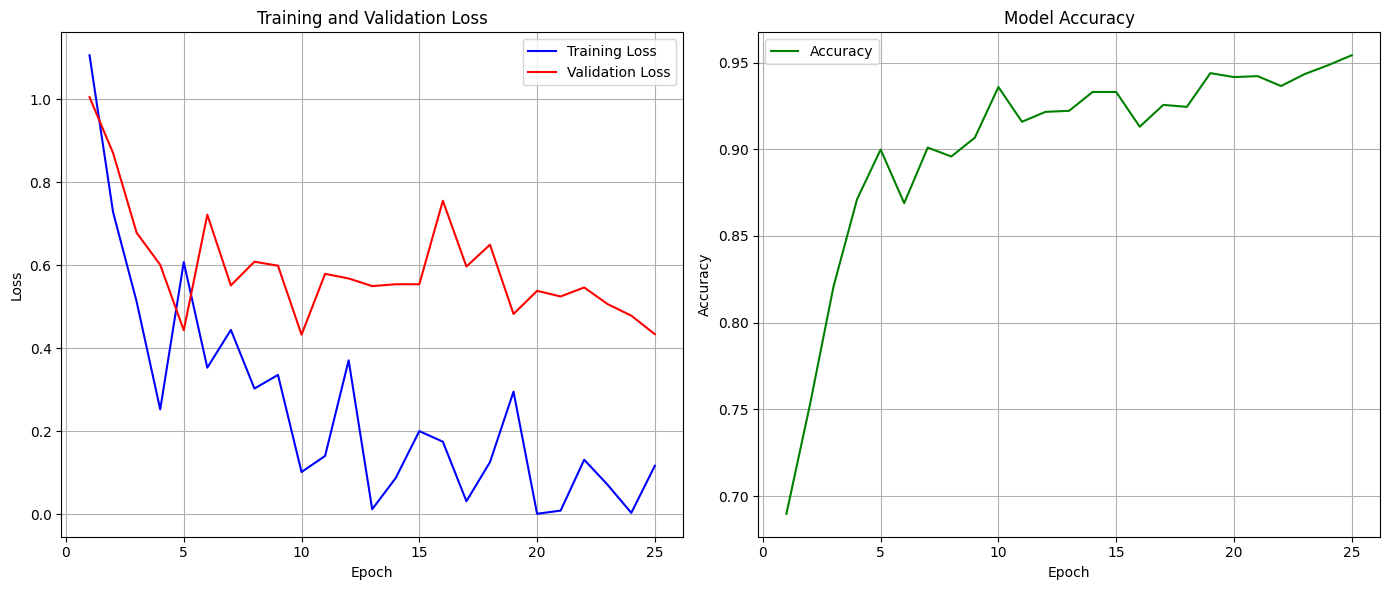

In [3]:
import matplotlib.pyplot as plt

# Your data
epochs = list(range(1, 26))
training_loss = [1.1060, 0.7276, 0.5119, 0.2523, 0.6073, 0.3529, 0.4440, 0.3026, 0.3355,
                 0.1014, 0.1402, 0.3706, 0.0117, 0.0871, 0.2000, 0.1745, 0.0310, 0.1252,
                 0.2951, 0.0007, 0.0084, 0.1310, 0.0703, 0.0029, 0.1165]
validation_loss = [1.004974, 0.870237, 0.678035, 0.600936, 0.443071, 0.721686, 0.551188,
                   0.608323, 0.598726, 0.432463, 0.579061, 0.567978, 0.549570, 0.554019,
                   0.553938, 0.755339, 0.596832, 0.649297, 0.482323, 0.538108, 0.524592,
                   0.546246, 0.506014, 0.478345, 0.433669]
accuracy = [0.689754, 0.752719, 0.820836, 0.871208, 0.899828, 0.868918, 0.900973, 0.895821,
            0.906697, 0.935890, 0.915856, 0.921580, 0.922152, 0.933028, 0.933028, 0.912994,
            0.925587, 0.924442, 0.943904, 0.941614, 0.942187, 0.936463, 0.943331, 0.948483,
            0.954207]

# Create figure with two subplots
plt.figure(figsize=(14, 6))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, training_loss, 'b-', label='Training Loss')
plt.plot(epochs, validation_loss, 'r-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracy, 'g-', label='Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()